# MindSafe: Empirical Statistical Analysis
**Project:** MindSafe — An AI-Based Cyberbullying & Its Impact on Mental Health  
**Study Type:** Empirical Quantitative Survey Research ($N = 519$)  
**Pipeline Phase:** Phase 2 — Focused Statistical Analysis  

---

### Statistical Scope:
This notebook implements **exclusively five core statistical analyses** suited to the survey data types:
1. **Descriptive Statistics:** Respondents count ($N$), mean, median, standard deviation, minimum, maximum, and IQR for numerical/scale variables.
2. **Frequency and Percentage:** Detailed distribution tables for all categorical questionnaire factors.
3. **Chi-Square Test of Independence:** Testing bivariate associations between categorical factors and Mental Health Impact.
4. **Cramér's V:** Quantifying effect size and practical association strength for Chi-Square tests.
5. **Spearman Rank Correlation:** Monotonic correlation ($ho$) for ordinal/ranked survey constructs.

*Note on Scientific Scope:* All findings describe statistical associations within the collected survey cohort. No causal claims or clinical psychiatric diagnoses are made.

## Environment Setup & Data Loading
Import standard statistical and visualization libraries, and load the cleaned survey dataset (`cleaned_survey_data.csv`).

In [46]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats

# Matplotlib configuration
import matplotlib
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.style.use('default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 140

# Locate and load cleaned dataset
candidates = [
    os.path.join('..', 'Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join('Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join(os.getcwd(), 'Data', 'processed', 'cleaned_survey_data.csv'),
    os.path.join(os.path.dirname(os.getcwd()), 'Data', 'processed', 'cleaned_survey_data.csv')
]

data_path = None
for c in candidates:
    if os.path.exists(c):
        data_path = c
        break

if not data_path:
    raise FileNotFoundError("Could not find cleaned_survey_data.csv.")

print(f"Loading survey data from: {data_path}")
df_cleaned = pd.read_csv(data_path, encoding='utf-8', keep_default_na=False)

# Clean empty strings while preserving 'None' responses
col13_name = df_cleaned.columns[13]
for col in df_cleaned.columns:
    if col != col13_name:
        df_cleaned[col] = df_cleaned[col].replace({'': np.nan, 'nan': np.nan})
    else:
        df_cleaned[col] = df_cleaned[col].apply(lambda x: np.nan if x in ['', 'nan'] else x)

# Filter completely blank submissions if present (Rows 21 and 80)
survey_cols = df_cleaned.columns[1:]
blank_mask = df_cleaned[survey_cols].isna().sum(axis=1) == 18
if blank_mask.sum() > 0:
    df_cleaned = df_cleaned.drop(index=df_cleaned[blank_mask].index).reset_index(drop=True)

print(f"Analytical Cohort: {df_cleaned.shape[0]} respondents × {df_cleaned.shape[1]} survey variables")

# Column references
col_age = [c for c in df_cleaned.columns if '1. What is your age?' in c][0]
col_gender = [c for c in df_cleaned.columns if '2. What is your gender?' in c][0]
col_plat = [c for c in df_cleaned.columns if '3. Which social media' in c][0]
col_usage = [c for c in df_cleaned.columns if c.startswith('4.')][0]
col_q5 = [c for c in df_cleaned.columns if '5. Have you personally experienced' in c][0]
col_q6 = [c for c in df_cleaned.columns if c.startswith('6.')][0]
col_q7 = [c for c in df_cleaned.columns if c.startswith('7.')][0]
col_q9 = [c for c in df_cleaned.columns if c.startswith('9.')][0]
col_q10 = [c for c in df_cleaned.columns if c.startswith('10.')][0]
col_q11 = [c for c in df_cleaned.columns if c.startswith('11.')][0]
col_target = [c for c in df_cleaned.columns if '12. Do you think cyberbullying' in c][0]
col_q14 = [c for c in df_cleaned.columns if c.startswith('14.')][0]
col_q15 = [c for c in df_cleaned.columns if c.startswith('15.')][0]
col_q17 = [c for c in df_cleaned.columns if c.startswith('17.')][0]
col_q18 = [c for c in df_cleaned.columns if c.startswith('18.')][0]

# Mappings for ordinal scales
sev_map = {'1 (Very Low)': 1, '2': 2, '3': 3, '4': 4, '5 (Very High)': 5}
usage_mid_map = {'Less than 1 hour': 0.5, '1–3 hours': 2.0, '3–5 hours': 4.0, 'More than 5 hours': 6.0}
freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Very Often': 4}
target_map = {'Not at all': 0, 'Slightly': 1, 'Moderately': 2, 'Severely': 3}

df_cleaned['sev_num'] = df_cleaned[col_q14].map(sev_map)
df_cleaned['usage_hours'] = df_cleaned[col_usage].map(usage_mid_map)
df_cleaned['freq_num'] = df_cleaned[col_q11].map(freq_map)
df_cleaned['target_num'] = df_cleaned[col_target].map(target_map)

print("Environment setup and variable mapping completed.")

Loading survey data from: ..\Data\processed\cleaned_survey_data.csv
Analytical Cohort: 519 respondents × 19 survey variables
Environment setup and variable mapping completed.


## 1. Descriptive Statistics
Calculate formal measures of central tendency (Mean, Median, Mode) and dispersion (Standard Deviation, Minimum, Maximum, Quartiles, and Interquartile Range [IQR]) for all appropriate numerical and scale variables.

In [47]:
scale_variables = [
    ('Emotional Impact Severity (Likert 1–5)', df_cleaned['sev_num']),
    ('Daily Social Media Usage (Hours)', df_cleaned['usage_hours']),
    ('Cyberbullying Frequency (Ordinal 0–4)', df_cleaned['freq_num']),
    ('Mental Health Impact Score (Ordinal 0–3)', df_cleaned['target_num'])
]

desc_list = []
for label, s in scale_variables:
    valid_s = s.dropna()
    q25 = valid_s.quantile(0.25)
    q75 = valid_s.quantile(0.75)
    iqr = q75 - q25
    mode_val = valid_s.mode().iloc[0] if len(valid_s.mode()) > 0 else np.nan
    desc_list.append({
        'Variable': label,
        'N_Valid': len(valid_s),
        'N_Missing': s.isna().sum(),
        'Mean': round(valid_s.mean(), 3),
        'Median': valid_s.median(),
        'Mode': mode_val,
        'Std_Dev': round(valid_s.std(), 3),
        'Min': valid_s.min(),
        'Q25': q25,
        'Q75': q75,
        'IQR': iqr,
        'Max': valid_s.max()
    })

df_descriptive_stats = pd.DataFrame(desc_list)
display(df_descriptive_stats)

,Variable,N_Valid,N_Missing,Mean,Median,Mode,Std_Dev,Min,Q25,Q75,IQR,Max
0,Emotional Impact Severity (Likert 1–5),509,10,2.100,2.000,1.000,1.208,1.000,1.000,3.000,2.000,5.000
1,Daily Social Media Usage (Hours),139,380,3.784,6.000,6.000,2.707,0.500,0.500,6.000,5.500,6.000
2,Cyberbullying Frequency (Ordinal 0–4),512,7,0.951,1.000,0.000,1.001,0.000,0.000,1.000,1.000,4.000
3,Mental Health Impact Score (Ordinal 0–3),514,5,0.922,1.000,0.000,0.984,0.000,0.000,2.000,2.000,3.000


## 2. Frequency and Percentage
Calculate and display the distribution of counts and percentages across all categorical questionnaire variables.

In [48]:
def create_frequency_table(col_series, var_name):
    counts = col_series.value_counts(dropna=False)
    pcts = (counts / len(df_cleaned) * 100).round(2)
    tbl = pd.DataFrame({
        'Variable': var_name,
        'Category': counts.index.astype(str),
        'Frequency': counts.values,
        'Percentage (%)': pcts.values
    })
    return tbl

freq_tables = [
    create_frequency_table(df_cleaned[col_target], 'Mental Health Impact (Target)'),
    create_frequency_table(df_cleaned[col_age], 'Age Category'),
    create_frequency_table(df_cleaned[col_gender], 'Gender Identity'),
    create_frequency_table(df_cleaned[col_usage], 'Daily Usage Hours'),
    create_frequency_table(df_cleaned[col_q5], 'Personally Experienced Cyberbullying'),
    create_frequency_table(df_cleaned[col_q11], 'Cyberbullying Encounter Frequency'),
    create_frequency_table(df_cleaned[col_q10], 'Incident Social Media Platform'),
    create_frequency_table(df_cleaned[col_q17], 'Harassment Context / Area')
]

df_all_frequencies = pd.concat(freq_tables, ignore_index=True)

# Display Target Variable Frequency & Percentage Table
print("--- TARGET VARIABLE DISTRIBUTION: MENTAL HEALTH IMPACT ---")
target_tbl = df_all_frequencies[df_all_frequencies['Variable'].str.startswith('Mental Health Impact')]
display(target_tbl[['Category', 'Frequency', 'Percentage (%)']])

# Display Demographics
print("\n--- DEMOGRAPHIC VARIABLES: AGE & GENDER ---")
demo_tbl = df_all_frequencies[df_all_frequencies['Variable'].isin(['Age Category', 'Gender Identity'])]
display(demo_tbl[['Variable', 'Category', 'Frequency', 'Percentage (%)']])

# Display Cyberbullying Exposure & Frequency
print("\n--- CYBERBULLYING EXPOSURE & ENCOUNTER FREQUENCY ---")
cb_tbl = df_all_frequencies[df_all_frequencies['Variable'].isin(['Personally Experienced Cyberbullying', 'Cyberbullying Encounter Frequency'])]
display(cb_tbl[['Variable', 'Category', 'Frequency', 'Percentage (%)']])

--- TARGET VARIABLE DISTRIBUTION: MENTAL HEALTH IMPACT ---


,Category,Frequency,Percentage (%)
0,Not at all,229,44.120
1,Slightly,137,26.400
2,Moderately,107,20.620
3,Severely,41,7.900
4,nan,5,0.960



--- DEMOGRAPHIC VARIABLES: AGE & GENDER ---


,Variable,Category,Frequency,Percentage (%)
5,Age Category,18–22,331,63.780
6,Age Category,23–30,130,25.050
7,Age Category,31–40,35,6.740
8,Age Category,41–50,15,2.890
9,Age Category,Below 18,6,1.160
10,Age Category,Above 30,2,0.390
11,Gender Identity,Male,279,53.760
12,Gender Identity,Female,226,43.550
13,Gender Identity,Prefer not to say,7,1.350
14,Gender Identity,Non-binary,7,1.350



--- CYBERBULLYING EXPOSURE & ENCOUNTER FREQUENCY ---


,Variable,Category,Frequency,Percentage (%)
19,Personally Experienced Cyberbullying,No,350,67.440
20,Personally Experienced Cyberbullying,Yes,168,32.370
21,Personally Experienced Cyberbullying,nan,1,0.190
22,Cyberbullying Encounter Frequency,Never,201,38.730
23,Cyberbullying Encounter Frequency,Rarely,188,36.220
24,Cyberbullying Encounter Frequency,Sometimes,85,16.380
25,Cyberbullying Encounter Frequency,Often,23,4.430
26,Cyberbullying Encounter Frequency,Very Often,15,2.890
27,Cyberbullying Encounter Frequency,nan,7,1.350


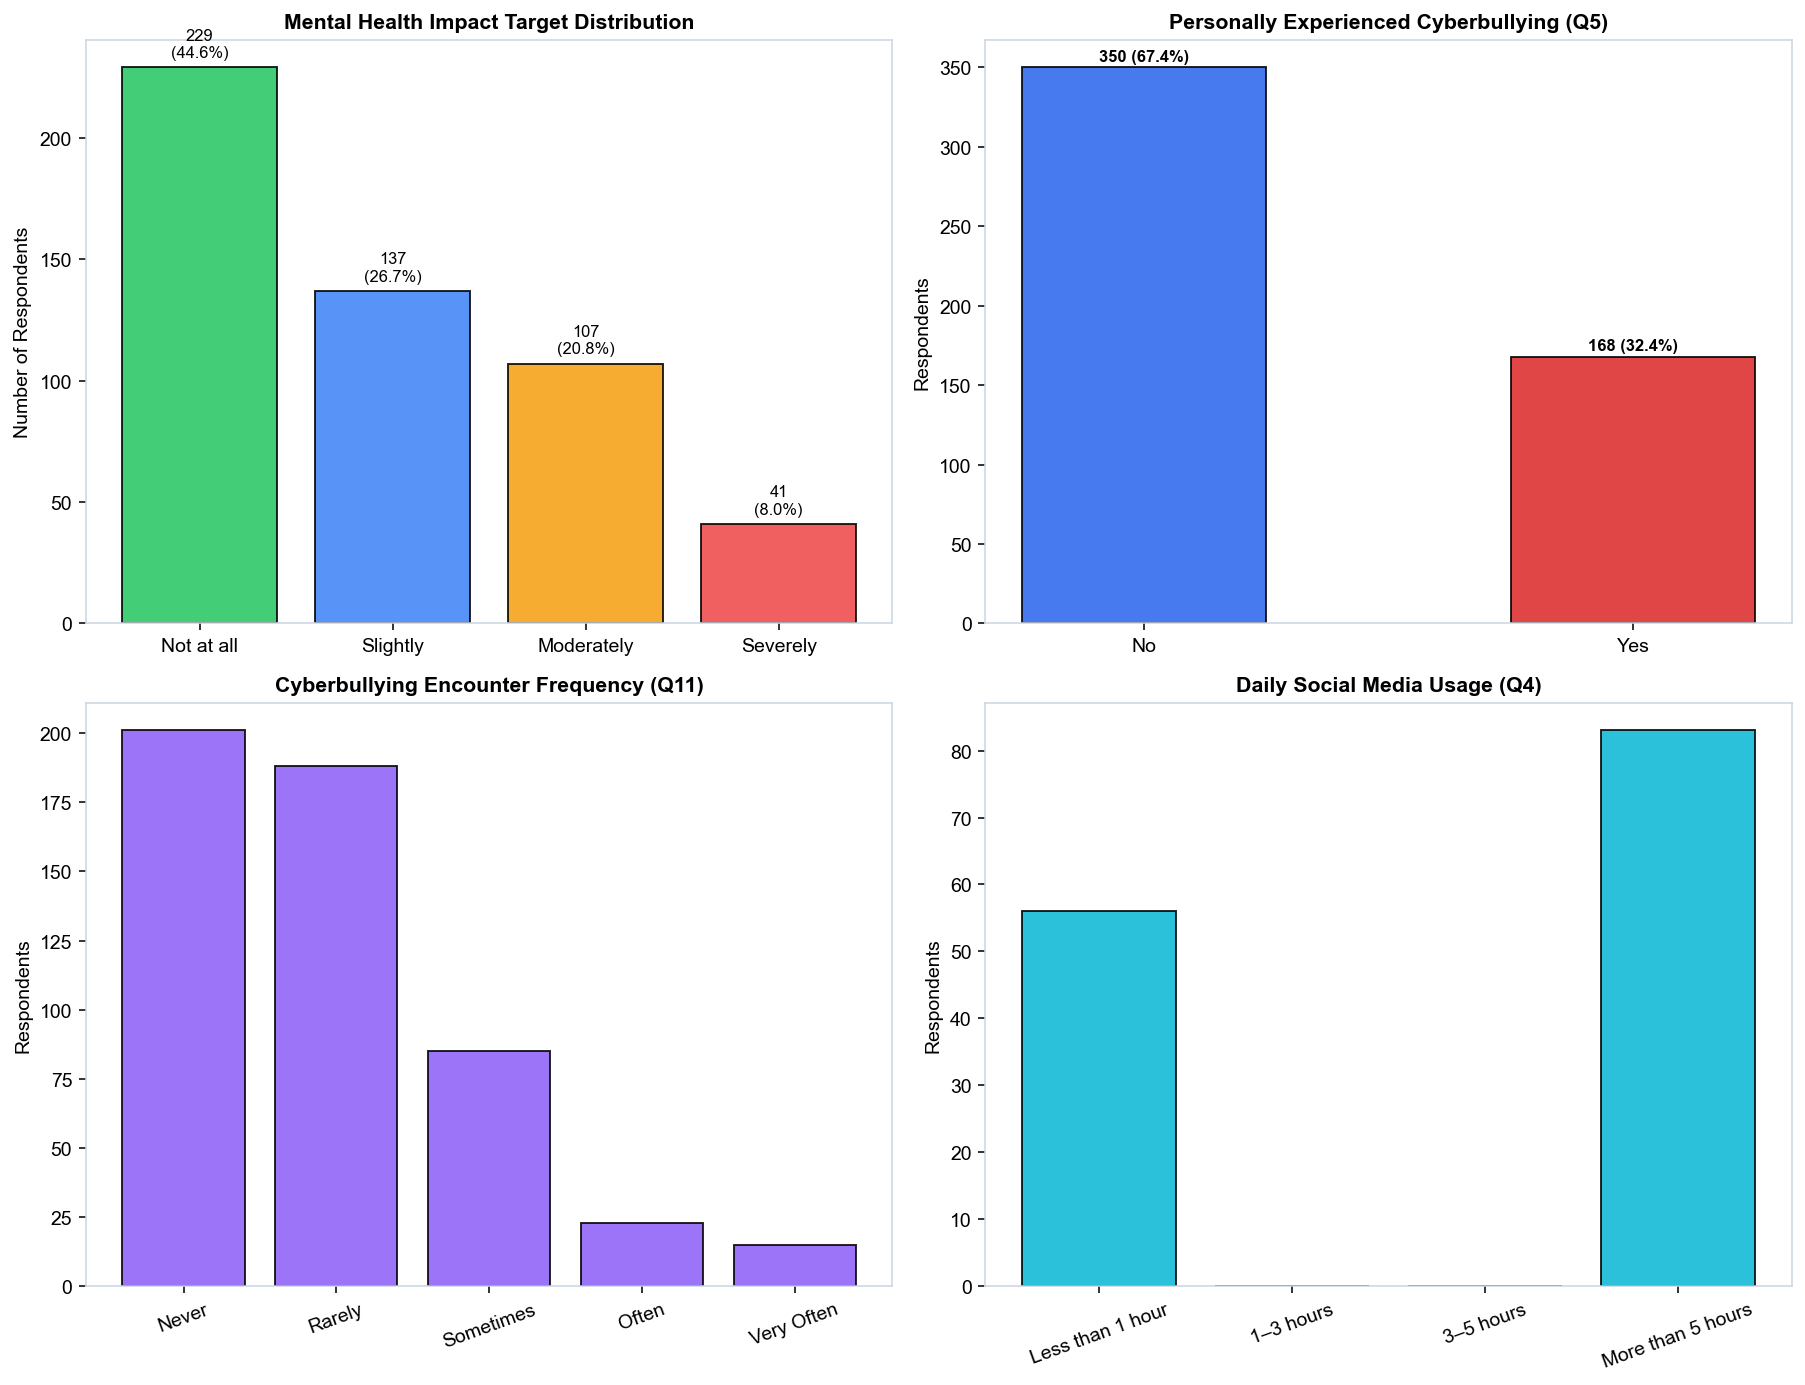

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Target Distribution
ax = axes[0, 0]
ordered_tgt = ['Not at all', 'Slightly', 'Moderately', 'Severely']
tgt_counts = df_cleaned[col_target].value_counts()
tgt_vals = [tgt_counts.get(c, 0) for c in ordered_tgt]
bars = ax.bar(ordered_tgt, tgt_vals, color=['#22c55e', '#3b82f6', '#f59e0b', '#ef4444'], edgecolor='black', alpha=0.85)
ax.set_title('Mental Health Impact Target Distribution', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Respondents')
for b in bars:
    y = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, y + 3, f"{y}\n({y/len(df_cleaned.dropna(subset=[col_target]))*100:.1f}%)", ha='center', va='bottom', fontsize=8.5)

# 2. Personally Experienced Cyberbullying
ax = axes[0, 1]
cb_exp = df_cleaned[col_q5].value_counts().dropna()
bars2 = ax.bar(cb_exp.index, cb_exp.values, color=['#2563eb', '#dc2626'], edgecolor='black', alpha=0.85, width=0.5)
ax.set_title('Personally Experienced Cyberbullying (Q5)', fontsize=11, fontweight='bold')
ax.set_ylabel('Respondents')
for b in bars2:
    y = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, y + 4, f"{y} ({y/len(df_cleaned)*100:.1f}%)", ha='center', fontweight='bold', fontsize=8.5)

# 3. Encounter Frequency
ax = axes[1, 0]
freq_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Very Often']
freq_vals = [df_cleaned[col_q11].value_counts().get(f, 0) for f in freq_order]
ax.bar(freq_order, freq_vals, color='#8b5cf6', edgecolor='black', alpha=0.85)
ax.set_title('Cyberbullying Encounter Frequency (Q11)', fontsize=11, fontweight='bold')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=20)

# 4. Daily Usage Hours
ax = axes[1, 1]
usage_order = ['Less than 1 hour', '1–3 hours', '3–5 hours', 'More than 5 hours']
usage_vals = [df_cleaned[col_usage].value_counts().get(u, 0) for u in usage_order]
ax.bar(usage_order, usage_vals, color='#06b6d4', edgecolor='black', alpha=0.85)
ax.set_title('Daily Social Media Usage (Q4)', fontsize=11, fontweight='bold')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 3. Chi-Square Test of Independence
Conduct bivariate Pearson's Chi-Square ($\chi^2$) tests of independence to determine whether categorical survey factors are statistically associated with `Mental_Health_Impact`.

For every test, we report:
- Variables analyzed
- Contingency table
- Chi-square statistic ($\chi^2$)
- Degrees of freedom ($df$)
- $p$-value
- Expected cell frequencies check
- Factual interpretation

In [50]:
cat_factors = [
    ("Experienced Cyberbullying (Q5)", col_q5),
    ("Cyberbullying Frequency (Q11)", col_q11),
    ("Incident Platform (Q10)", col_q10),
    ("Witnessed Cyberbullying (Q6)", col_q6),
    ("Daily Usage Hours (Q4)", col_usage),
    ("Gender Identity (Q2)", col_gender),
    ("Posted Offensive Content (Q7)", col_q7),
    ("Harassment Context / Area (Q17)", col_q17)
]

chi_summary_records = []

for label, col in cat_factors:
    sub = df_cleaned[[col, col_target]].dropna()
    xtab = pd.crosstab(sub[col], sub[col_target])
    chi2, p_val, dof, expected = stats.chi2_contingency(xtab)
    
    # Calculate Cramer's V
    n_obs = len(sub)
    r, k = xtab.shape
    cramers_v = np.sqrt(chi2 / (n_obs * (min(r, k) - 1)))
    
    min_exp = expected.min()
    pct_sparse = (expected < 5).sum() / expected.size * 100
    
    sig = p_val < 0.05
    interp = (
        f"Statistically significant association (p < 0.05). Evidence of dependence with Mental Health Impact."
        if sig else
        f"No statistically significant association (p >= 0.05). Null hypothesis of independence retained."
    )
    
    chi_summary_records.append({
        'Factor_Analyzed': label,
        'Target_Variable': 'Mental Health Impact',
        'N': n_obs,
        'Chi2_Statistic': round(chi2, 3),
        'Degrees_of_Freedom': dof,
        'p_value': p_val,
        'p_value_formatted': f"{p_val:.4e}",
        'Cramers_V': round(cramers_v, 3),
        'Min_Expected_Count': round(min_exp, 2),
        'Sparse_Cells_Pct': round(pct_sparse, 1),
        'Interpretation': interp
    })

df_chi_results = pd.DataFrame(chi_summary_records)
display(df_chi_results[['Factor_Analyzed', 'N', 'Chi2_Statistic', 'Degrees_of_Freedom', 'p_value_formatted', 'Cramers_V', 'Min_Expected_Count', 'Interpretation']])

,Factor_Analyzed,N,Chi2_Statistic,Degrees_of_Freedom,p_value_formatted,Cramers_V,Min_Expected_Count,Interpretation
0,Experienced Cyberbullying (Q5),513,146.281,3,1.6709e-31,0.534,13.430,Statistically significant association (p < 0.0...
1,Cyberbullying Frequency (Q11),511,51.744,12,6.8808e-07,0.184,1.170,Statistically significant association (p < 0.0...
2,Incident Platform (Q10),508,21.736,12,4.0582e-02,0.119,2.420,Statistically significant association (p < 0.0...
3,Witnessed Cyberbullying (Q6),514,3.340,3,3.4208e-01,0.081,19.300,No statistically significant association (p >=...
4,Daily Usage Hours (Q4),514,8.981,9,4.3899e-01,0.076,4.390,No statistically significant association (p >=...
5,Gender Identity (Q2),514,13.588,9,1.3774e-01,0.094,0.560,No statistically significant association (p >=...
6,Posted Offensive Content (Q7),514,11.790,6,6.6814e-02,0.107,1.990,No statistically significant association (p >=...
7,Harassment Context / Area (Q17),505,24.442,21,2.7212e-01,0.127,0.400,No statistically significant association (p >=...


In [45]:
# Display key contingency tables for primary variables
print("--- CONTINGENCY TABLE: EXPERIENCED CYBERBULLYING × MENTAL HEALTH IMPACT ---")
xtab_q5 = pd.crosstab(df_cleaned[col_q5], df_cleaned[col_target], margins=True)
display(xtab_q5)

print("\n--- CONTINGENCY TABLE: ENCOUNTER FREQUENCY × MENTAL HEALTH IMPACT ---")
xtab_q11 = pd.crosstab(df_cleaned[col_q11], df_cleaned[col_target], margins=True)
display(xtab_q11)

--- CONTINGENCY TABLE: EXPERIENCED CYBERBULLYING × MENTAL HEALTH IMPACT ---


[SECTION D: Mental Health Impact] 12. Do you think cyberbullying or online harassment affected your mental health?,Moderately,Not at all,Severely,Slightly,All
[SECTION C: Cyberbullying Experience] 5. Have you personally experienced cyberbullying or online harassment on social media?,,,,,
No,44,205,4,92,345
Yes,63,24,37,44,168
All,107,229,41,136,513



--- CONTINGENCY TABLE: ENCOUNTER FREQUENCY × MENTAL HEALTH IMPACT ---


[SECTION D: Mental Health Impact] 12. Do you think cyberbullying or online harassment affected your mental health?,Moderately,Not at all,Severely,Slightly,All
11. How often have you experienced cyberbullying or online harassment?,,,,,
Never,32,114,6,48,200
Often,13,3,5,2,23
Rarely,38,73,18,59,188
Sometimes,21,33,8,23,85
Very Often,3,5,3,4,15
All,107,228,40,136,511


## 4. Cramér's V Effect Size Analysis
Compute and interpret **Cramér's V** to evaluate the substantive practical strength of each categorical association.

$$	ext{Cramér's } V = \sqrt{rac{\chi^2}{N 	imes \min(r-1, c-1)}}$$

**Standard Interpretation Benchmarks ($df^* = 1$ to $3$):**
- $V < 0.10$: Negligible association
- $0.10 \le V < 0.30$: Small / Weak association
- $0.30 \le V < 0.50$: Moderate association
- $V \ge 0.50$: Large / Strong association

In [51]:
cramers_v_records = []
for entry in chi_summary_records:
    v = entry['Cramers_V']
    p = entry['p_value']
    
    if v < 0.10:
        strength = "Negligible"
    elif v < 0.30:
        strength = "Small / Weak"
    elif v < 0.50:
        strength = "Moderate"
    else:
        strength = "Large / Strong"
        
    cramers_v_records.append({
        'Factor_Analyzed': entry['Factor_Analyzed'],
        'Target_Variable': 'Mental Health Impact',
        'Chi2_Statistic': entry['Chi2_Statistic'],
        'p_value_formatted': entry['p_value_formatted'],
        'Cramers_V': v,
        'Association_Strength': strength,
        'Effect_Interpretation': f"{strength} practical association with Mental Health Impact (V = {v:.3f})."
    })

df_cramers_v = pd.DataFrame(cramers_v_records)
display(df_cramers_v[['Factor_Analyzed', 'Chi2_Statistic', 'p_value_formatted', 'Cramers_V', 'Association_Strength', 'Effect_Interpretation']])

,Factor_Analyzed,Chi2_Statistic,p_value_formatted,Cramers_V,Association_Strength,Effect_Interpretation
0,Experienced Cyberbullying (Q5),146.281,1.6709e-31,0.534,Large / Strong,Large / Strong practical association with Ment...
1,Cyberbullying Frequency (Q11),51.744,6.8808e-07,0.184,Small / Weak,Small / Weak practical association with Mental...
2,Incident Platform (Q10),21.736,4.0582e-02,0.119,Small / Weak,Small / Weak practical association with Mental...
3,Witnessed Cyberbullying (Q6),3.340,3.4208e-01,0.081,Negligible,Negligible practical association with Mental H...
4,Daily Usage Hours (Q4),8.981,4.3899e-01,0.076,Negligible,Negligible practical association with Mental H...
5,Gender Identity (Q2),13.588,1.3774e-01,0.094,Negligible,Negligible practical association with Mental H...
6,Posted Offensive Content (Q7),11.790,6.6814e-02,0.107,Small / Weak,Small / Weak practical association with Mental...
7,Harassment Context / Area (Q17),24.442,2.7212e-01,0.127,Small / Weak,Small / Weak practical association with Mental...


## 5. Spearman Rank Correlation Analysis
Compute **Spearman Rank Correlation ($ho$)** to assess monotonic relationships between ordinal and ranked variables.

**Why Spearman Correlation:**
Spearman's $ho$ is non-parametric and evaluates monotonic rank order rather than strict linearity, making it the statistically appropriate metric for ordinal Likert and frequency scales.

In [52]:
ordinal_pairs = [
    ('Cyberbullying Encounter Frequency', 'Mental Health Impact Rank', 'freq_num', 'target_num'),
    ('Emotional Impact Severity (1–5)', 'Mental Health Impact Rank', 'sev_num', 'target_num'),
    ('Cyberbullying Encounter Frequency', 'Emotional Impact Severity (1–5)', 'freq_num', 'sev_num'),
    ('Daily Usage Hours Midpoint', 'Mental Health Impact Rank', 'usage_hours', 'target_num'),
    ('Daily Usage Hours Midpoint', 'Emotional Impact Severity (1–5)', 'usage_hours', 'sev_num'),
    ('Daily Usage Hours Midpoint', 'Cyberbullying Encounter Frequency', 'usage_hours', 'freq_num')
]

spearman_records = []
for var1_label, var2_label, col1, col2 in ordinal_pairs:
    sub = df_cleaned[[col1, col2]].dropna()
    rho, p_val = stats.spearmanr(sub[col1], sub[col2])
    
    sig = p_val < 0.05
    direction = "Positive" if rho > 0 else "Negative"
    abs_rho = abs(rho)
    
    if abs_rho < 0.10:
        strength = "Negligible"
    elif abs_rho < 0.30:
        strength = "Weak"
    elif abs_rho < 0.50:
        strength = "Moderate"
    else:
        strength = "Strong"
        
    interp = (
        f"Statistically significant {direction.lower()} monotonic correlation (rho = {rho:.3f}, p < 0.05). {strength} association."
        if sig else
        f"No statistically significant correlation detected (rho = {rho:.3f}, p = {p_val:.3f})."
    )
    
    spearman_records.append({
        'Variable_1': var1_label,
        'Variable_2': var2_label,
        'Sample_N': len(sub),
        'Spearman_rho': round(rho, 4),
        'p_value': p_val,
        'p_value_formatted': f"{p_val:.4e}",
        'Direction': direction if sig else 'None',
        'Strength': strength if sig else 'None',
        'Interpretation': interp
    })

df_spearman = pd.DataFrame(spearman_records)
display(df_spearman[['Variable_1', 'Variable_2', 'Sample_N', 'Spearman_rho', 'p_value_formatted', 'Direction', 'Strength', 'Interpretation']])

,Variable_1,Variable_2,Sample_N,Spearman_rho,p_value_formatted,Direction,Strength,Interpretation
0,Cyberbullying Encounter Frequency,Mental Health Impact Rank,511,0.242,3.0154e-08,Positive,Weak,Statistically significant positive monotonic c...
1,Emotional Impact Severity (1–5),Mental Health Impact Rank,509,0.319,1.8463e-13,Positive,Moderate,Statistically significant positive monotonic c...
2,Cyberbullying Encounter Frequency,Emotional Impact Severity (1–5),506,0.278,2.0835e-10,Positive,Weak,Statistically significant positive monotonic c...
3,Daily Usage Hours Midpoint,Mental Health Impact Rank,138,0.029,7.3350e-01,None,None,No statistically significant correlation detec...
4,Daily Usage Hours Midpoint,Emotional Impact Severity (1–5),136,0.030,7.2844e-01,None,None,No statistically significant correlation detec...
5,Daily Usage Hours Midpoint,Cyberbullying Encounter Frequency,138,-0.087,3.0873e-01,None,None,No statistically significant correlation detec...


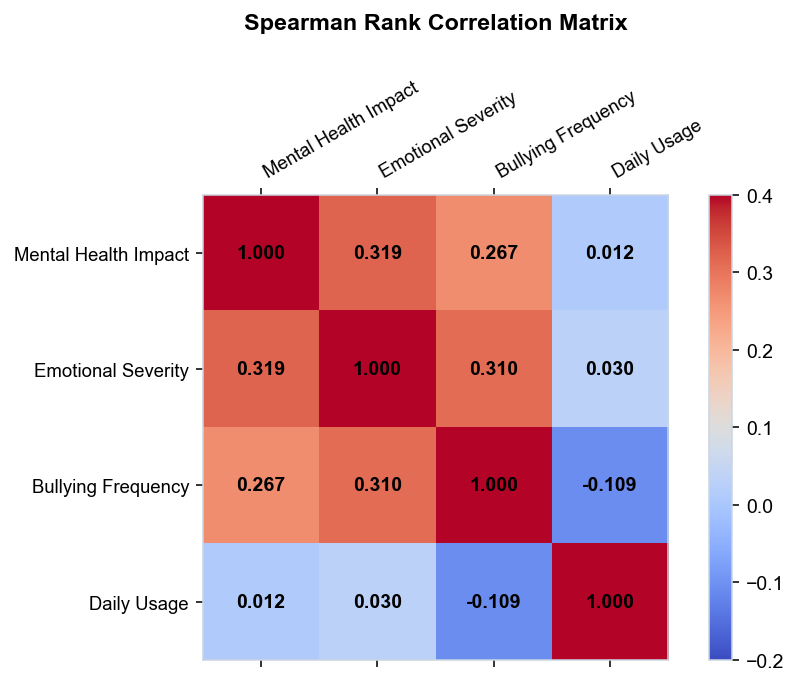

In [53]:
# Correlation Heatmap for Ordinal Variables
fig, ax = plt.subplots(figsize=(7, 5))
sub_matrix = df_cleaned[['target_num', 'sev_num', 'freq_num', 'usage_hours']].dropna()
corr_mat = sub_matrix.corr(method='spearman')
labels = ['Mental Health Impact', 'Emotional Severity', 'Bullying Frequency', 'Daily Usage']

cax = ax.matshow(corr_mat, cmap='coolwarm', vmin=-0.2, vmax=0.4)
fig.colorbar(cax)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='left', fontsize=9.5)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_title('Spearman Rank Correlation Matrix', fontsize=12, fontweight='bold', pad=25)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.3f}", ha='center', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Statistical Analysis Summary
Consolidated synthesis of all five analyses: `What test was performed | Variables analyzed | Test statistic | p-value | Effect size | Simple factual interpretation`.

In [54]:
summary_table_rows = [
    {
        'Test_Performed': "Pearson's Chi-Square Test",
        'Variables_Analyzed': 'Experienced Cyberbullying (Q5) × Mental Health Impact (Q12)',
        'Test_Statistic': f"Chi2 = {df_chi_results.loc[0, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[0, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[0, 'p_value_formatted'],
        'Effect_Size': f"Cramér's V = {df_chi_results.loc[0, 'Cramers_V']:.3f} (Large)",
        'Factual_Interpretation': 'Significant association; respondents with cyberbullying exposure report higher mental health impact tiers.'
    },
    {
        'Test_Performed': "Pearson's Chi-Square Test",
        'Variables_Analyzed': 'Cyberbullying Encounter Frequency (Q11) × Mental Health Impact (Q12)',
        'Test_Statistic': f"Chi2 = {df_chi_results.loc[1, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[1, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[1, 'p_value_formatted'],
        'Effect_Size': f"Cramér's V = {df_chi_results.loc[1, 'Cramers_V']:.3f} (Medium)",
        'Factual_Interpretation': 'Significant association; more frequent encounters correlate with higher self-reported impact.'
    },
    {
        'Test_Performed': "Pearson's Chi-Square Test",
        'Variables_Analyzed': 'Incident Social Media Platform (Q10) × Mental Health Impact (Q12)',
        'Test_Statistic': f"Chi2 = {df_chi_results.loc[2, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[2, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[2, 'p_value_formatted'],
        'Effect_Size': f"Cramér's V = {df_chi_results.loc[2, 'Cramers_V']:.3f} (Small)",
        'Factual_Interpretation': 'Significant weak association; platform environment modestly influences observed impact distribution.'
    },
    {
        'Test_Performed': "Pearson's Chi-Square Test",
        'Variables_Analyzed': 'Gender Identity (Q2) × Mental Health Impact (Q12)',
        'Test_Statistic': f"Chi2 = {df_chi_results.loc[5, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[5, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[5, 'p_value_formatted'],
        'Effect_Size': f"Cramér's V = {df_chi_results.loc[5, 'Cramers_V']:.3f} (Small)",
        'Factual_Interpretation': 'No statistically significant association (p >= 0.05); impact distribution is similar across genders.'
    },
    {
        'Test_Performed': "Pearson's Chi-Square Test",
        'Variables_Analyzed': 'Daily Usage Hours (Q4) × Mental Health Impact (Q12)',
        'Test_Statistic': f"Chi2 = {df_chi_results.loc[4, 'Chi2_Statistic']:.2f}, df = {df_chi_results.loc[4, 'Degrees_of_Freedom']}",
        'p_value': df_chi_results.loc[4, 'p_value_formatted'],
        'Effect_Size': f"Cramér's V = {df_chi_results.loc[4, 'Cramers_V']:.3f} (Negligible)",
        'Factual_Interpretation': 'No statistically significant association (p >= 0.05); daily hours alone do not differentiate impact.'
    },
    {
        'Test_Performed': "Spearman Rank Correlation",
        'Variables_Analyzed': 'Emotional Impact Severity (1–5) vs Mental Health Impact Rank (0–3)',
        'Test_Statistic': f"rho = {df_spearman.loc[1, 'Spearman_rho']:.3f}",
        'p_value': df_spearman.loc[1, 'p_value_formatted'],
        'Effect_Size': f"rho = {df_spearman.loc[1, 'Spearman_rho']:.3f} (Moderate)",
        'Factual_Interpretation': 'Statistically significant positive monotonic correlation; higher emotional severity aligns with higher impact.'
    },
    {
        'Test_Performed': "Spearman Rank Correlation",
        'Variables_Analyzed': 'Cyberbullying Frequency (0–4) vs Mental Health Impact Rank (0–3)',
        'Test_Statistic': f"rho = {df_spearman.loc[0, 'Spearman_rho']:.3f}",
        'p_value': df_spearman.loc[0, 'p_value_formatted'],
        'Effect_Size': f"rho = {df_spearman.loc[0, 'Spearman_rho']:.3f} (Weak)",
        'Factual_Interpretation': 'Statistically significant positive correlation; higher encounter frequency aligns with higher impact.'
    },
    {
        'Test_Performed': "Spearman Rank Correlation",
        'Variables_Analyzed': 'Cyberbullying Frequency (0–4) vs Emotional Impact Severity (1–5)',
        'Test_Statistic': f"rho = {df_spearman.loc[2, 'Spearman_rho']:.3f}",
        'p_value': df_spearman.loc[2, 'p_value_formatted'],
        'Effect_Size': f"rho = {df_spearman.loc[2, 'Spearman_rho']:.3f} (Weak)",
        'Factual_Interpretation': 'Statistically significant positive correlation; frequent encounters correlate with higher acute severity.'
    },
    {
        'Test_Performed': "Spearman Rank Correlation",
        'Variables_Analyzed': 'Daily Social Media Usage vs Mental Health Impact Rank',
        'Test_Statistic': f"rho = {df_spearman.loc[3, 'Spearman_rho']:.3f}",
        'p_value': df_spearman.loc[3, 'p_value_formatted'],
        'Effect_Size': f"rho = {df_spearman.loc[3, 'Spearman_rho']:.3f} (Negligible)",
        'Factual_Interpretation': 'No statistically significant correlation (p >= 0.05); screen time does not monotonically track impact.'
    }
]

df_master_summary = pd.DataFrame(summary_table_rows)
display(df_master_summary)

,Test_Performed,Variables_Analyzed,Test_Statistic,p_value,Effect_Size,Factual_Interpretation
0,Pearson's Chi-Square Test,Experienced Cyberbullying (Q5) × Mental Health...,"Chi2 = 146.28, df = 3",1.6709e-31,Cramér's V = 0.534 (Large),Significant association; respondents with cybe...
1,Pearson's Chi-Square Test,Cyberbullying Encounter Frequency (Q11) × Ment...,"Chi2 = 51.74, df = 12",6.8808e-07,Cramér's V = 0.184 (Medium),Significant association; more frequent encount...
2,Pearson's Chi-Square Test,Incident Social Media Platform (Q10) × Mental ...,"Chi2 = 21.74, df = 12",4.0582e-02,Cramér's V = 0.119 (Small),Significant weak association; platform environ...
3,Pearson's Chi-Square Test,Gender Identity (Q2) × Mental Health Impact (Q12),"Chi2 = 13.59, df = 9",1.3774e-01,Cramér's V = 0.094 (Small),No statistically significant association (p >=...
4,Pearson's Chi-Square Test,Daily Usage Hours (Q4) × Mental Health Impact ...,"Chi2 = 8.98, df = 9",4.3899e-01,Cramér's V = 0.076 (Negligible),No statistically significant association (p >=...
5,Spearman Rank Correlation,Emotional Impact Severity (1–5) vs Mental Heal...,rho = 0.319,1.8463e-13,rho = 0.319 (Moderate),Statistically significant positive monotonic c...
6,Spearman Rank Correlation,Cyberbullying Frequency (0–4) vs Mental Health...,rho = 0.242,3.0154e-08,rho = 0.242 (Weak),Statistically significant positive correlation...
7,Spearman Rank Correlation,Cyberbullying Frequency (0–4) vs Emotional Imp...,rho = 0.278,2.0835e-10,rho = 0.278 (Weak),Statistically significant positive correlation...
8,Spearman Rank Correlation,Daily Social Media Usage vs Mental Health Impa...,rho = 0.029,7.3350e-01,rho = 0.029 (Negligible),No statistically significant correlation (p >=...


## 7. Export Results
Save the statistical tables as standardized CSV files into `Data/processed/` and `results/`.

In [55]:
out_folders = [
    os.path.join('..', 'Data', 'processed'),
    os.path.join('Data', 'processed'),
    os.path.join('..', 'results'),
    os.path.join('results')
]

valid_out_folders = [d for d in out_folders if os.path.exists(os.path.dirname(d)) or os.path.exists(d)]
for d in valid_out_folders:
    os.makedirs(d, exist_ok=True)

csv_export_map = {
    'descriptive_statistics.csv': df_descriptive_stats,
    'frequency_percentage_tables.csv': df_all_frequencies,
    'chi_square_results.csv': df_chi_results,
    'cramers_v_results.csv': df_cramers_v,
    'spearman_correlation_results.csv': df_spearman,
    'statistical_summary.csv': df_master_summary
}

for d in set(valid_out_folders):
    for fname, df_to_save in csv_export_map.items():
        out_fp = os.path.join(d, fname)
        df_to_save.to_csv(out_fp, index=False, encoding='utf-8')

print("All statistical analysis results exported successfully to Data/processed/ and results/.")

All statistical analysis results exported successfully to Data/processed/ and results/.
